In [1]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('darkgrid')
sns.set(font_scale=1.3)

In [2]:
# loads the wine dataset and returns a bunch object
data = load_wine()

In [3]:
# inspect the data
data

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]], shape=(178, 13)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [4]:
# feature names
data.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [5]:
# target names
data.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [6]:
# combine two numpy arrays of different dimensions using column_stack
wine = pd.DataFrame(
    data=np.column_stack((data['data'], data['target'])),
    columns=data['feature_names'] + ['target']
)

In [7]:
wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2.0


In [8]:
# check for null values in any of the columns
wine.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [9]:
# check the info on dataframe
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [42]:
# univariate analysis

In [43]:
wine.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


<Axes: xlabel='alcohol', ylabel='Count'>

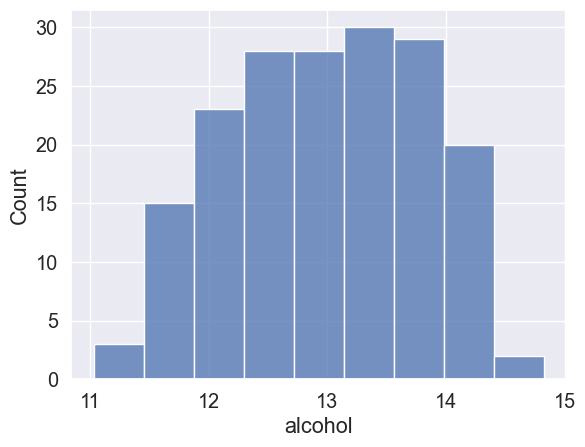

In [44]:
# histogram gives a frequency distribution - gives range of data, skewness and outliers
sns.histplot(x='alcohol', data=wine)

array([[<Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'malic_acid'}>,
        <Axes: title={'center': 'ash'}>,
        <Axes: title={'center': 'alcalinity_of_ash'}>],
       [<Axes: title={'center': 'magnesium'}>,
        <Axes: title={'center': 'total_phenols'}>,
        <Axes: title={'center': 'flavanoids'}>,
        <Axes: title={'center': 'nonflavanoid_phenols'}>],
       [<Axes: title={'center': 'proanthocyanins'}>,
        <Axes: title={'center': 'color_intensity'}>,
        <Axes: title={'center': 'hue'}>,
        <Axes: title={'center': 'od280/od315_of_diluted_wines'}>],
       [<Axes: title={'center': 'proline'}>,
        <Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

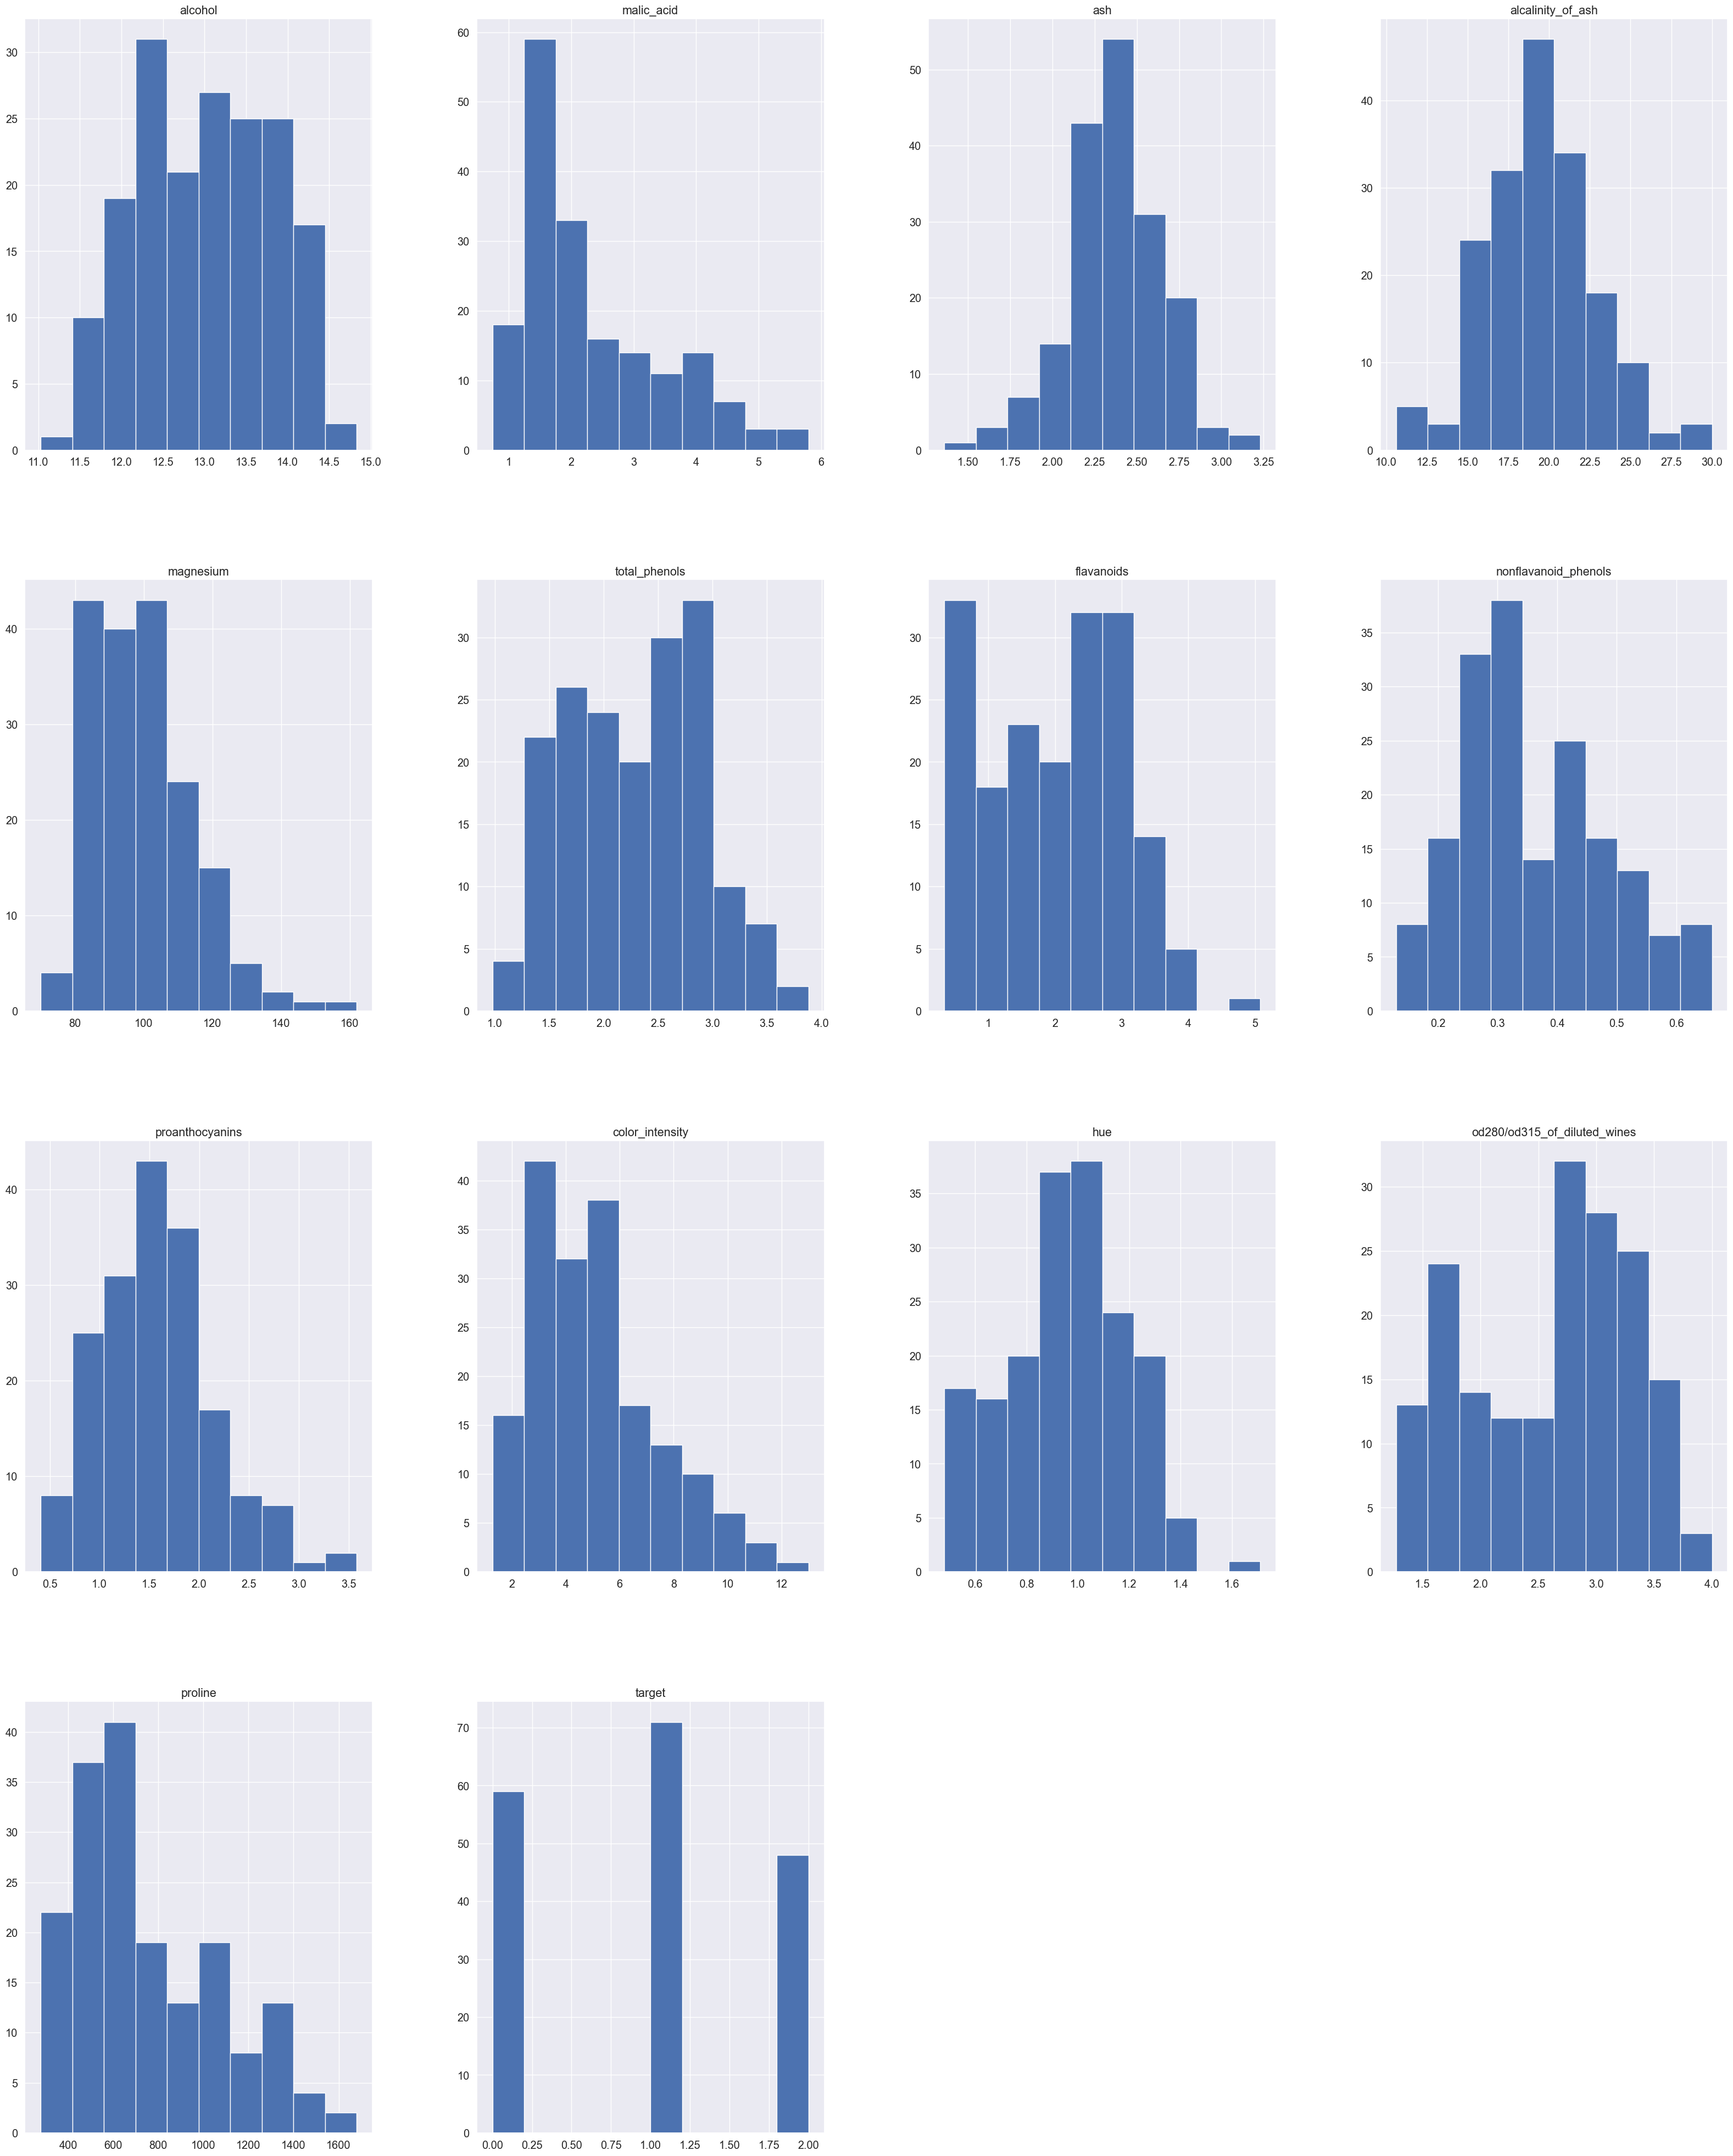

In [56]:
# plotting a histogram for all columns
wine.hist(figsize=(40, 50))

In [57]:
# kdeplot compares 2 variables, the hue preferably a categorical or discrete variable

<Axes: xlabel='alcohol', ylabel='Density'>

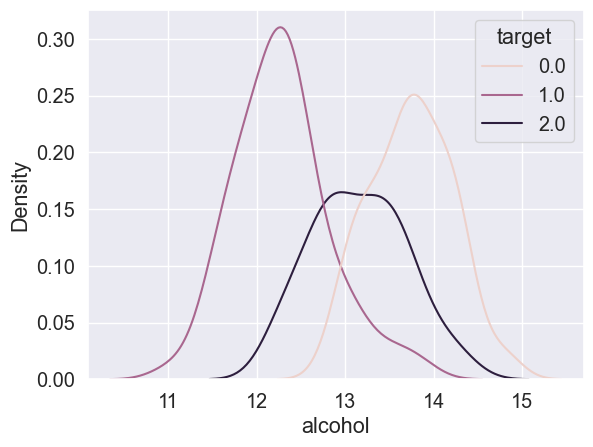

In [59]:
sns.kdeplot(x='alcohol', data=wine, hue='target')

In [60]:
# boxplot shows the distribution, center and skewness of particular feature

<Axes: xlabel='magnesium'>

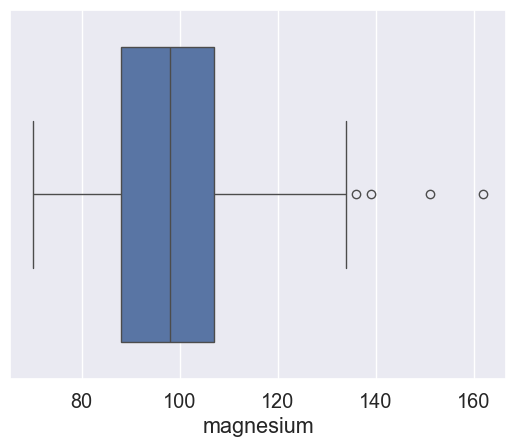

In [62]:
# the small circles at the end indicate outliers
sns.boxplot(x=wine['magnesium'])

In [63]:
# using boxplot to compare the distribution of multiple columns

<Axes: >

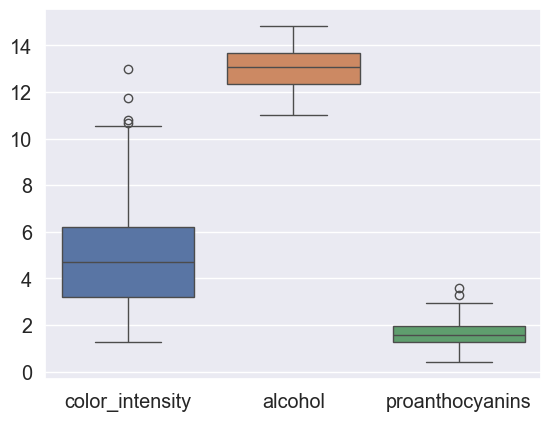

In [71]:
sns.boxplot(data=wine.loc[:, ['color_intensity', 'alcohol', 'proanthocyanins']])

In [72]:
# value counts

In [75]:
wine['target'].value_counts()

target
1.0    71
0.0    59
2.0    48
Name: count, dtype: int64

<Axes: >

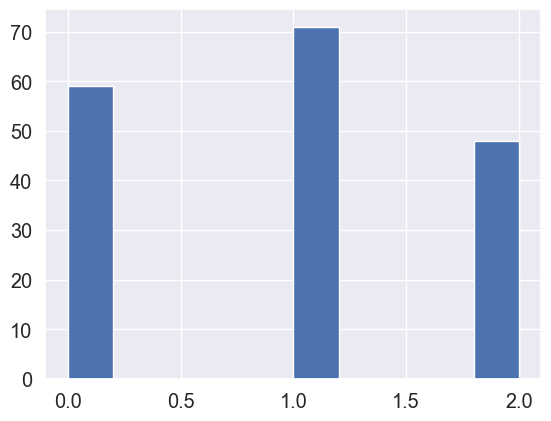

In [78]:
wine['target'].hist()

In [79]:
# bivariate analysis

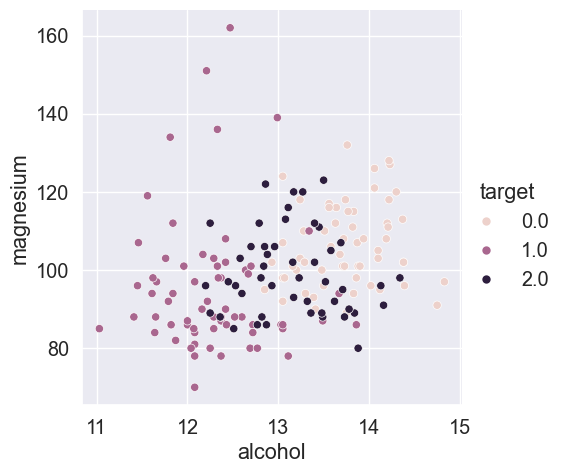

In [82]:
# scatterplot
sns.relplot(x="alcohol", y="magnesium", hue="target", data=wine)

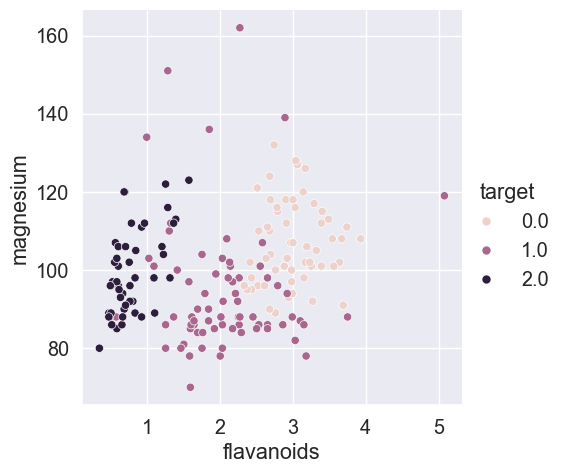

In [83]:
sns.relplot(x="flavanoids", y="magnesium", hue="target", data=wine)

In [84]:
# correlation table

In [85]:
wine.corr()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720,-0.328222
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011,0.437776
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626,-0.049643
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597,0.517859
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351,-0.209179
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115,-0.719163
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193,-0.847498
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385,0.489109
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417,-0.499130
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100,0.265668


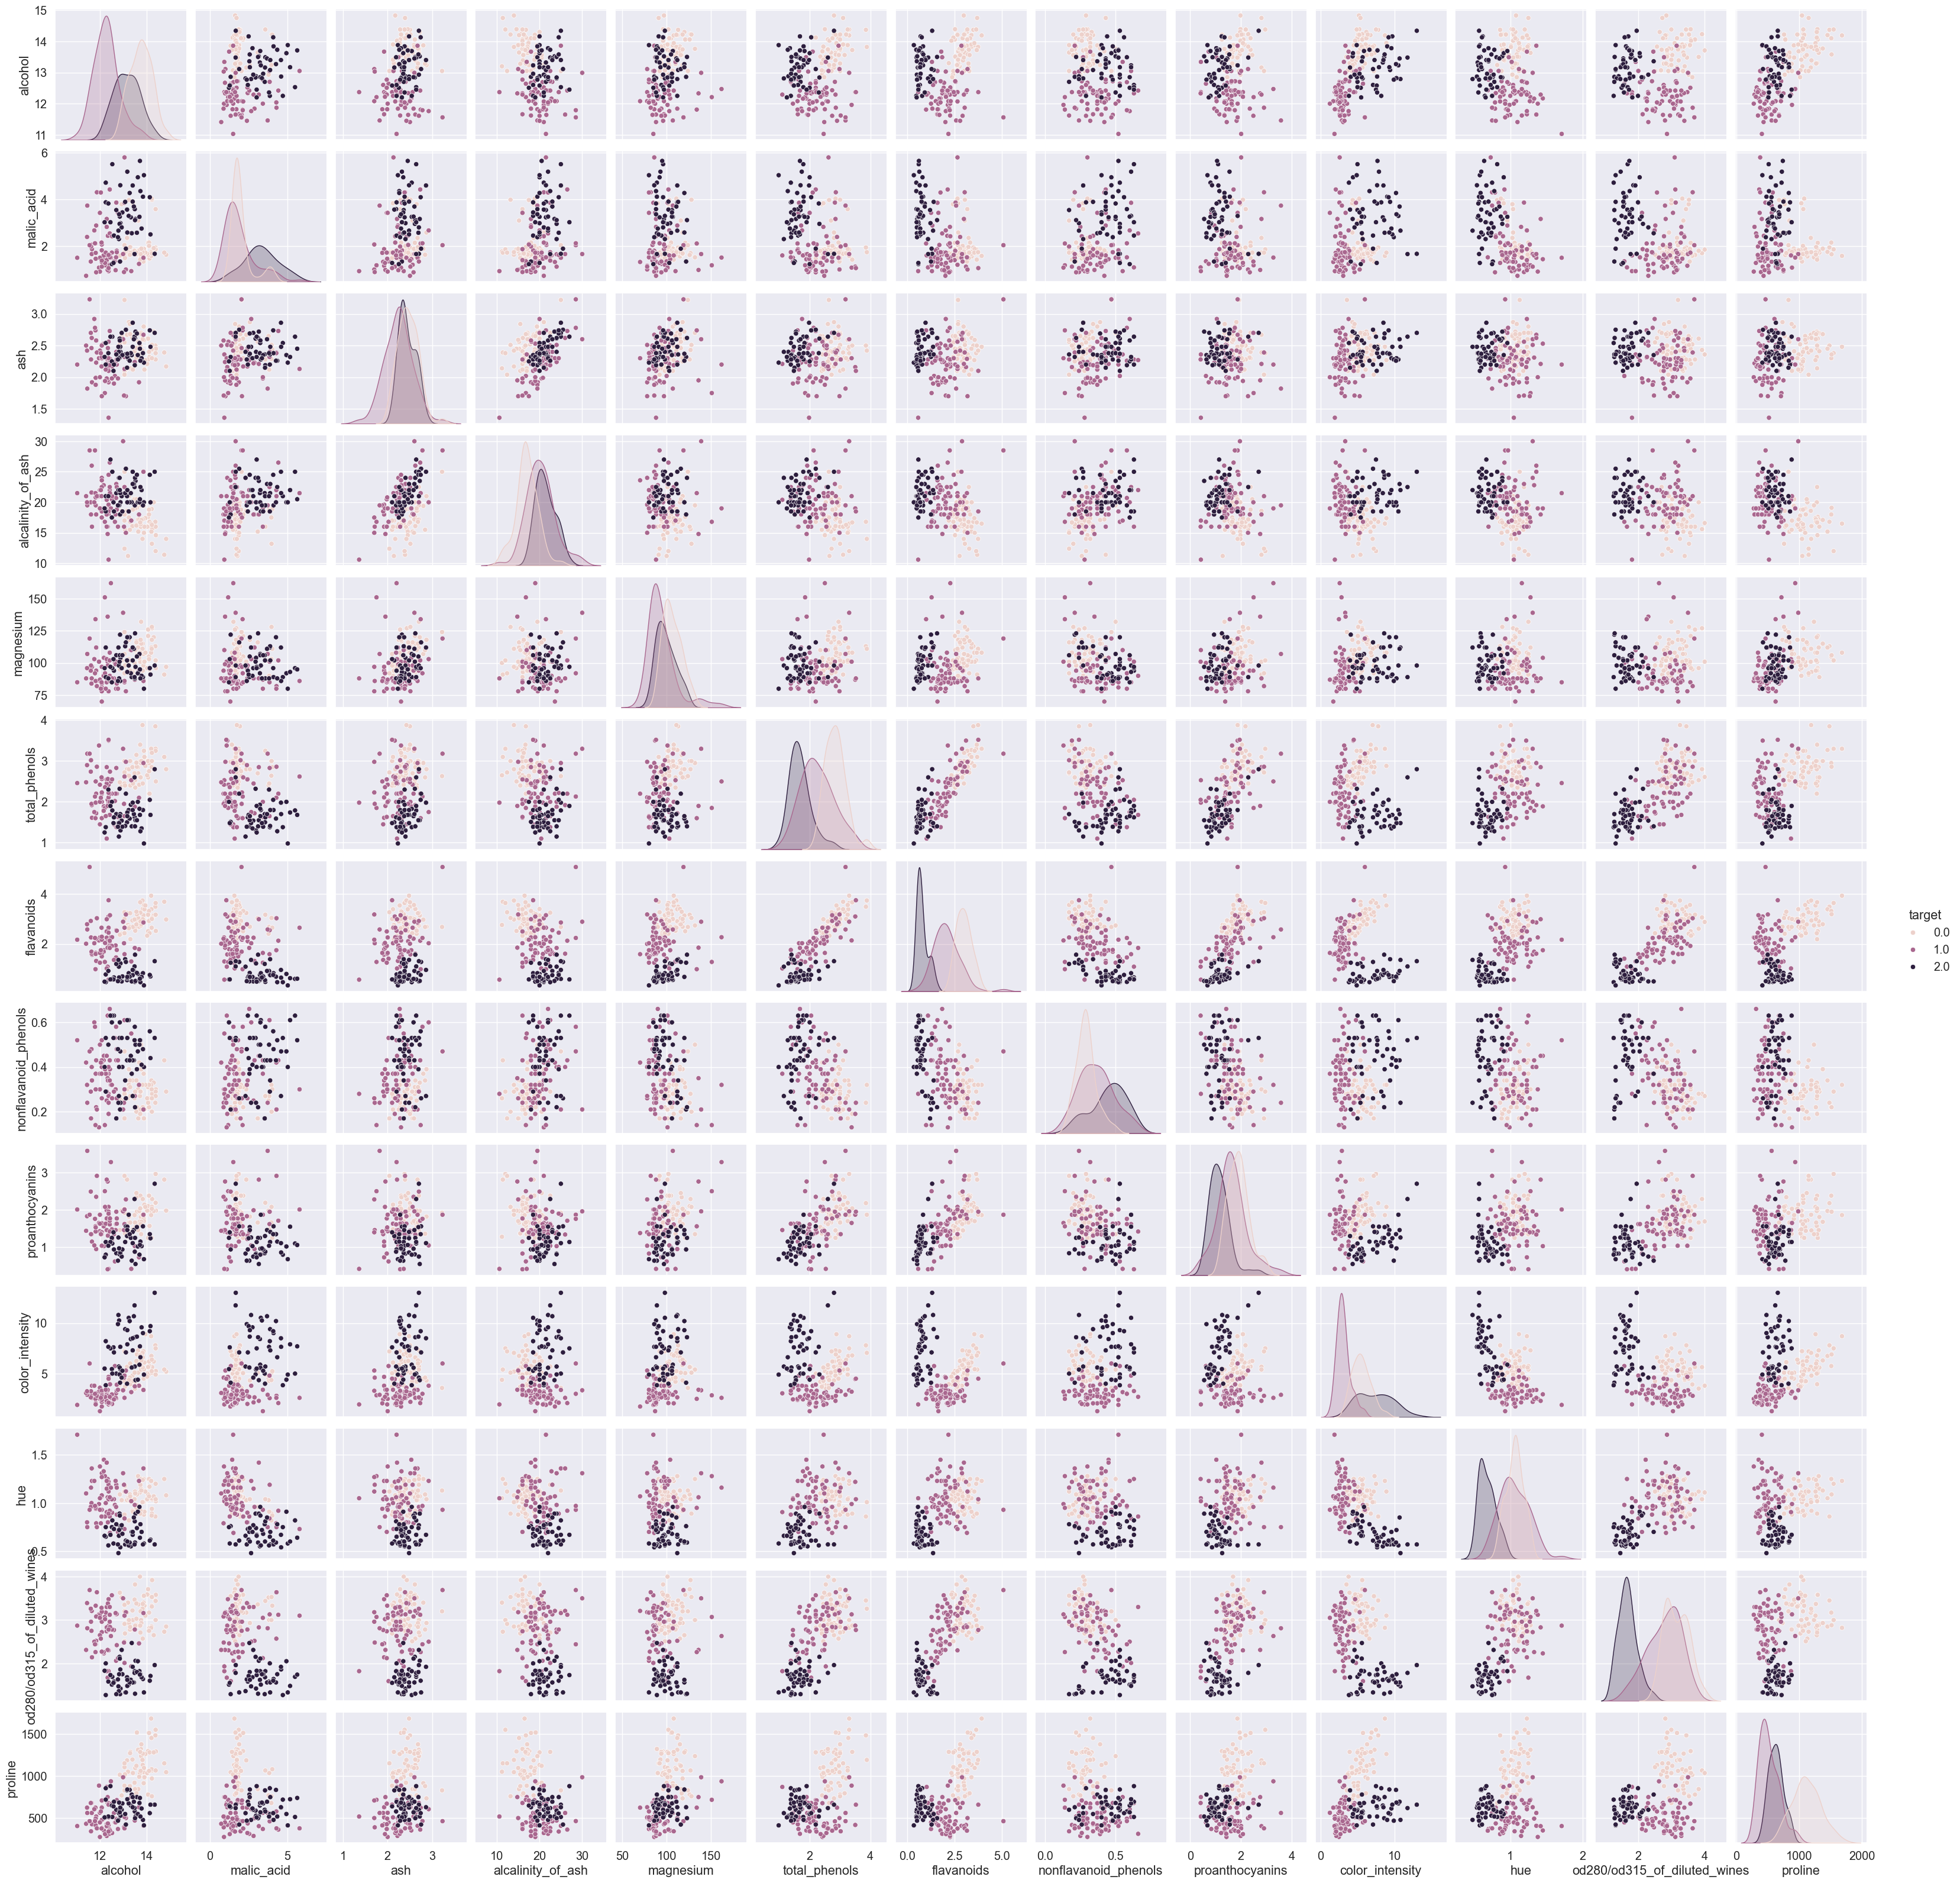

In [86]:
sns.pairplot(wine, hue='target')

In [88]:
# apply PCA to reduce dimensions

In [91]:
x = wine.loc[:,wine.columns != 'target'].values
y = wine.loc[:,['target']].values

In [94]:
x = pd.DataFrame(StandardScaler().fit_transform(x))

In [95]:
x

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.876275,2.974543,0.305159,0.301803,-0.332922,-0.985614,-1.424900,1.274310,-0.930179,1.142811,-1.392758,-1.231206,-0.021952
174,0.493343,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.549108,-0.316950,0.969783,-1.129518,-1.485445,0.009893
175,0.332758,1.744744,-0.389355,0.151661,1.422412,-1.129824,-1.344582,0.549108,-0.422075,2.224236,-1.612125,-1.485445,0.280575
176,0.209232,0.227694,0.012732,0.151661,1.422412,-1.033684,-1.354622,1.354888,-0.229346,1.834923,-1.568252,-1.400699,0.296498


In [97]:
pca = PCA(n_components=2)

In [98]:
pca_computed = pca.fit_transform(x)

In [99]:
pca_wine = pd.DataFrame(data = pca_computed, columns = ['PC 1', 'PC 2'])

In [100]:
pca_wine

,PC 1,PC 2
0,3.316751,-1.443463
1,2.209465,0.333393
2,2.516740,-1.031151
3,3.757066,-2.756372
4,1.008908,-0.869831
...,...,...
173,-3.370524,-2.216289
174,-2.601956,-1.757229
175,-2.677839,-2.760899
176,-2.387017,-2.297347


In [101]:
pca_wine_final = pd.concat([pca_wine, wine[['target']]], axis = 1)

In [102]:
pca_wine_final

,PC 1,PC 2,target
0,3.316751,-1.443463,0.0
1,2.209465,0.333393,0.0
2,2.516740,-1.031151,0.0
3,3.757066,-2.756372,0.0
4,1.008908,-0.869831,0.0
...,...,...,...
173,-3.370524,-2.216289,2.0
174,-2.601956,-1.757229,2.0
175,-2.677839,-2.760899,2.0
176,-2.387017,-2.297347,2.0


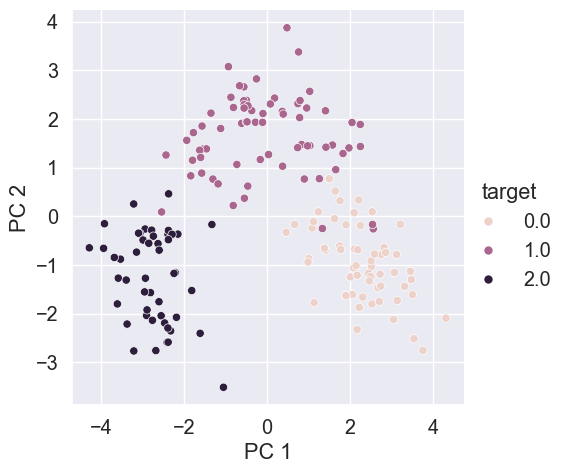

In [104]:
# indicates how well the classes are separated from each other
sns.relplot(x=pca_wine_final['PC 1'], y=pca_wine_final['PC 2'], hue='target', data=pca_wine_final)

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.33,
    random_state=42
)

In [109]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((119, 13), (59, 13), (119, 1), (59, 1))

In [112]:
clf = RandomForestClassifier(n_estimators=10, random_state=42)

In [114]:
clf.fit(X_train,y_train)

/Users/manojkumarrajendran/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(n_estimators=10, random_state=42)

In [116]:
y_pred = clf.predict(X_test)

In [138]:
y_pred

array([0., 0., 2., 0., 1., 0., 1., 2., 1., 2., 0., 2., 0., 1., 0., 1., 1.,
       1., 0., 1., 0., 1., 1., 2., 2., 2., 1., 1., 1., 0., 0., 1., 2., 0.,
       0., 0., 1., 2., 1., 1., 0., 1., 1., 1., 2., 0., 1., 1., 2., 0., 1.,
       0., 0., 2., 2., 1., 1., 0., 1.])

In [117]:
# does prediction for all data points of X_test and compares the predictions with the ground truth lables
clf.score(X_test, y_test)

0.9661016949152542

In [ ]:
# verify the accuracy using different approach

In [126]:
df_with_preds = pd.DataFrame(np.column_stack((X_test, y_test, y_pred)))

In [128]:
df_with_preds['accuracy'] = df_with_preds[14] == df_with_preds[13]

In [137]:
(df_with_preds['accuracy'].sum() / len(df_with_preds['accuracy'])) * 100

96.61016949152543

In [140]:
df_with_preds

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,accuracy
0,0.789806,0.685502,0.707247,-1.289707,1.141558,0.648764,1.004700,-1.545922,0.121071,0.018129,0.011190,1.056952,0.312420,0.0,0.0,True
1,1.493907,1.529305,0.268606,-0.178653,0.790492,0.889114,0.623193,-0.498407,-0.597284,0.078689,-0.383670,1.014578,1.060776,0.0,0.0,True
2,-0.087232,0.425180,1.218995,0.451946,-0.262708,-1.209940,-1.535336,1.354888,-1.473326,-0.198156,-0.822404,-0.426113,-0.467781,2.0,2.0,True
3,0.900980,-0.750759,1.218995,0.902373,0.088358,1.129464,1.225573,-0.578985,1.382572,0.277671,1.020278,0.138864,1.713598,0.0,0.0,True
4,-0.778980,-1.046988,-1.632171,0.031547,-1.526548,-0.296611,-0.029386,-0.740141,-0.965221,-0.163550,0.713164,1.226445,-0.754385,1.0,1.0,True
5,1.605081,-0.373741,1.292101,0.151661,1.422412,0.808997,1.115136,-0.256673,0.664217,0.493956,0.493797,0.054117,1.697675,0.0,0.0,True
6,-1.236028,0.981731,-1.339744,-0.148624,-0.894628,-0.472868,-0.390814,0.065639,0.489009,-1.634288,-0.120430,0.619094,-0.582422,1.0,1.0,True
7,0.493343,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.549108,-0.316950,0.969783,-1.129518,-1.485445,0.009893,2.0,2.0,True
8,-1.717782,-0.885409,1.218995,0.151661,-0.403135,0.712858,0.894264,-0.578985,1.575301,-1.041667,0.011190,0.915707,-0.213021,1.0,1.0,True
9,0.443932,0.200764,-0.060375,0.151661,-0.754202,-1.434267,-1.535336,0.065639,-1.666055,0.234414,-1.129518,-0.200123,0.105428,2.0,2.0,True


In [141]:
# iterate the experiment with PCA computed features

In [148]:
X_train, X_test, y_train, y_test = train_test_split(
    pca_wine_final[['PC 1', 'PC 2']], 
    pca_wine_final['target'], 
    test_size=0.33,
    random_state=42
)

In [149]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((119, 2), (59, 2), (119,), (59,))

In [150]:
clf = RandomForestClassifier(n_estimators=10, random_state=42)

In [151]:
clf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [152]:
y_pred = clf.predict(X_test)

In [153]:
clf.score(X_test, y_test)

0.9661016949152542